# Experiment 4 — PCom variants and fetal-PCA-like anatomy

## Goal

This experiment studies **posterior communicating artery (PCom) collateral capacity** and a simple **fetal-PCA-like variant**.

The question is:

> When posterior collateral anatomy changes, how are PCA territory perfusion and anterior/posterior collateral flows affected?

This is useful after the ICA stenosis and ACom experiments because the Circle of Willis has two major collateral routes:

1. anterior collateral route through the ACom;
2. posterior collateral route through the PCom arteries.

## Cases

The notebook generates several anatomy variants from `CoW_normal.json`:

| Case | Modification | Interpretation |
|---|---|---|
| `complete` | no change | complete CoW |
| `left_PCom_5pct` | `L-PCommA` area = 5% baseline | left PCom hypoplastic |
| `right_PCom_5pct` | `R-PCommA` area = 5% baseline | right PCom hypoplastic |
| `bilateral_PCom_5pct` | both PComs = 5% baseline | weak posterior collateral route |
| `left_fetal_PCA_like` | larger `L-PCommA`, smaller `L-PCA_I` | simplified fetal-PCA-like supply pattern |

The fetal-PCA-like case is a **surrogate**, not a full anatomical reconstruction. It encourages the left PCA territory to be supplied more from the carotid/PCom side and less from the basilar/PCA-I side.

## Interpretation

Expected qualitative behavior:

- PCom hypoplasia should reduce posterior-to-anterior or anterior-to-posterior compensation.
- A fetal-PCA-like variant should make `L-PCA_bed` more sensitive to left carotid-side pressure and flow conditions.
- In this implementation, we compare trends rather than claiming exact clinical thresholds.

In [5]:
from __future__ import annotations

import copy
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import hemo1d as hd

MMHG_TO_DYN_CM2 = 1333.22


def mmhg(value: float) -> float:
    return value * MMHG_TO_DYN_CM2


def read_config(path: Path) -> dict:
    with Path(path).open() as f:
        return json.load(f)


def write_config(config: dict, path: Path) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open('w') as f:
        json.dump(config, f, indent=2)
    return path


def area_key(vessel: dict) -> str:
    for key in ('initial_area', 'area0', 'A0'):
        if key in vessel:
            return key
    raise KeyError('Vessel has no initial_area/area0/A0 field.')


def get_area(config: dict, vessel_id: str) -> float:
    vessel = config['vessels'][vessel_id]
    return float(vessel[area_key(vessel)])


def set_area(config: dict, vessel_id: str, area: float) -> None:
    vessel = config['vessels'][vessel_id]
    vessel[area_key(vessel)] = float(area)


def scale_area(config: dict, vessel_id: str, fraction: float) -> None:
    base_area = get_area(config, vessel_id)
    set_area(config, vessel_id, base_area * fraction)


def beta_key(vessel: dict) -> str:
    for key in ('beta_coeff', 'beta'):
        if key in vessel:
            return key
    raise KeyError('Vessel has no beta_coeff/beta field.')


def scale_beta(config: dict, vessel_id: str, factor: float) -> None:
    vessel = config['vessels'][vessel_id]
    key = beta_key(vessel)
    vessel[key] = float(vessel[key]) * factor


def set_all_vessel_pressures(config: dict, *, p0_mmhg: float = 80.0, p_ext_mmhg: float = 0.0) -> None:
    """Set a consistent resting reference pressure for every vessel."""
    config.setdefault('defaults', {})
    config['defaults']['p0'] = mmhg(p0_mmhg)
    config['defaults']['p_ext'] = mmhg(p_ext_mmhg)

    for vessel in config['vessels'].values():
        vessel['p0'] = mmhg(p0_mmhg)
        vessel['p_ext'] = mmhg(p_ext_mmhg)


def set_capillary_venous_pressure(config: dict, p_ven_mmhg: float) -> None:
    for bed in config.get('capillary_beds', {}).values():
        bed['P_ven'] = mmhg(p_ven_mmhg)


def set_capillary_initial_pressure(config: dict, p0_mmhg: float) -> None:
    for bed in config.get('capillary_beds', {}).values():
        bed['P0'] = mmhg(p0_mmhg)


def make_pressure_inlet(mean_mmhg: float, amp1_mmhg: float, amp2_mmhg: float, *, phase_s: float = 0.0):
    """Use the source-code waveform creator, not a notebook-local redefinition."""
    return hd.create_arterial_pressure_inflow(
        mean_mmhg=mean_mmhg,
        amp1_mmhg=amp1_mmhg,
        amp2_mmhg=amp2_mmhg,
        heart_rate=1.2,
        ramp_time=0.20,
        phase_s=phase_s,
    )


def install_pressure_inlets(model) -> None:
    model.set_inlet(
        vessel_id='L-ICA_I',
        side='right',
        kind='pressure',
        function=make_pressure_inlet(85.0, 14.0, 4.0, phase_s=0.00),
    )
    model.set_inlet(
        vessel_id='R-ICA_I',
        side='right',
        kind='pressure',
        function=make_pressure_inlet(85.0, 14.0, 4.0, phase_s=0.00),
    )
    model.set_inlet(
        vessel_id='BAS',
        side='left',
        kind='pressure',
        function=make_pressure_inlet(84.0, 11.0, 3.0, phase_s=0.04),
    )


def add_mid_probes(model, vessel_ids: tuple[str, ...]) -> None:
    for vessel_id in vessel_ids:
        if vessel_id not in model.config.vessels:
            continue
        length = model.config.vessel(vessel_id).length
        model.add_probe(vessel_id=vessel_id, position=0.5 * length, name='mid')


def configure_model(config_path: Path, *, probe_vessels: tuple[str, ...], method: str = 'CG'):
    model = hd.load_from_config(config_path)
    install_pressure_inlets(model)
    model.set_solver(
        method=method,
        h=0.0625,
        dt=1.0e-5,
        poly_order=1,
        dg_time_scheme='rk2',
        record_every=10,
    )
    add_mid_probes(model, probe_vessels)
    return model


def late_mask(times: np.ndarray, fraction: float = 0.25) -> np.ndarray:
    tail_start = times[-1] - fraction * (times[-1] - times[0])
    return times >= tail_start


def bed_late_means(results, bed_id: str) -> dict[str, float]:
    samples = results.capillary_bed_history(bed_id)
    times = np.array([s.time for s in samples])
    tail = late_mask(times)

    pcap_mmhg = np.array([s.pressure for s in samples]) / MMHG_TO_DYN_CM2
    inflow_ml_min = np.array([s.total_inflow for s in samples]) * 60.0
    venous_ml_min = np.array([s.venous_outflow for s in samples]) * 60.0
    perfusion = np.array([s.regional_perfusion for s in samples]) * 6000.0

    return {
        'Pcap [mmHg]': float(np.mean(pcap_mmhg[tail])),
        'Flow [mL/min]': float(np.mean(inflow_ml_min[tail])),
        'Venous out [mL/min]': float(np.mean(venous_ml_min[tail])),
        'Perfusion [mL/100g/min]': float(np.mean(perfusion[tail])),
        'Pcap min [mmHg]': float(np.min(pcap_mmhg[tail])),
        'Pcap max [mmHg]': float(np.max(pcap_mmhg[tail])),
    }


def summarize_beds(results, *, case: str) -> pd.DataFrame:
    rows = []
    for bed_id in results.capillary_bed_ids():
        row = {'case': case, 'bed': bed_id}
        row.update(bed_late_means(results, bed_id))
        rows.append(row)
    return pd.DataFrame(rows).sort_values(['case', 'bed'])


def probe_late_mean_flow(results, vessel_id: str, probe_name: str = 'mid') -> float | None:
    samples = results.history.probes.by_vessel_and_name(vessel_id, probe_name)
    if not samples:
        return None
    times = np.array([s.time for s in samples])
    tail = late_mask(times)
    q_ml_min = np.array([s.flow_rate for s in samples]) * 60.0
    return float(np.mean(q_ml_min[tail]))


def summarize_probe_flows(results, *, case: str, vessels: tuple[str, ...]) -> pd.DataFrame:
    rows = []
    for vessel_id in vessels:
        q = probe_late_mean_flow(results, vessel_id)
        if q is not None:
            rows.append({'case': case, 'vessel': vessel_id, 'mid flow [mL/min]': q})
    return pd.DataFrame(rows)


def plot_metric(summary: pd.DataFrame, *, x: str, y: str, hue: str | None = None, title: str = '') -> None:
    plt.figure(figsize=(8, 4.5))
    if hue is None:
        for bed, group in summary.groupby('bed'):
            plt.plot(group[x], group[y], marker='o', label=bed)
    else:
        for name, group in summary.groupby(hue):
            plt.plot(group[x], group[y], marker='o', label=str(name))
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

In [6]:
BASE_CONFIG_PATH = Path('./configs/CoW_normal.json')
GENERATED_CONFIG_DIR = Path('./configs/generated_notebooks/pcom_variants')
OUTPUT_ROOT = Path('./outputs/notebooks/04_pcom_variants')
T_END = 2.0
RUN_SIMULATIONS = True

PROBE_VESSELS = (
    'BAS', 'L-ICA_I', 'R-ICA_I',
    'L-PCommA', 'R-PCommA',
    'L-PCA_I', 'R-PCA_I', 'L-PCA_II', 'R-PCA_II',
    'L-MCA', 'R-MCA', 'L-ACA_II', 'R-ACA_II',
)

ANATOMY_CASES = {
    'complete': {},
    'left_PCom_5pct': {'L-PCommA': 0.05},
    'right_PCom_5pct': {'R-PCommA': 0.05},
    'bilateral_PCom_5pct': {'L-PCommA': 0.05, 'R-PCommA': 0.05},
}

In [7]:
def make_pcom_variant_config(case_name: str) -> Path:
    config = read_config(BASE_CONFIG_PATH)
    config = copy.deepcopy(config)
    set_all_vessel_pressures(config, p0_mmhg=80.0, p_ext_mmhg=0.0)
    set_capillary_initial_pressure(config, 35.0)
    set_capillary_venous_pressure(config, 8.0)

    if case_name == 'left_fetal_PCA_like':
        # Simplified surrogate:
        # - enlarge left PCom route
        # - reduce basilar-to-left-PCA proximal segment
        scale_area(config, 'L-PCommA', 2.5)
        scale_area(config, 'L-PCA_I', 0.35)
    else:
        for vessel_id, area_fraction in ANATOMY_CASES[case_name].items():
            scale_area(config, vessel_id, area_fraction)

    path = GENERATED_CONFIG_DIR / f'CoW_{case_name}.json'
    return write_config(config, path)


def run_case(case_name: str):
    config_path = make_pcom_variant_config(case_name)
    model = configure_model(config_path, probe_vessels=PROBE_VESSELS)
    results = model.solve(t_end=T_END, show_progress=True, progress_description=case_name)

    output_dir = OUTPUT_ROOT / case_name
    results.save(output_dir)
    results.plot_capillary_beds(output_dir / 'plots', show=False)
    return results

In [8]:
case_names = list(ANATOMY_CASES) + ['left_fetal_PCA_like']
all_beds = []
all_flows = []
results_by_case = {}

if RUN_SIMULATIONS:
    for case_name in case_names:
        results = run_case(case_name)
        results_by_case[case_name] = results
        all_beds.append(summarize_beds(results, case=case_name))
        all_flows.append(summarize_probe_flows(results, case=case_name, vessels=PROBE_VESSELS))

    bed_summary = pd.concat(all_beds, ignore_index=True)
    flow_summary = pd.concat(all_flows, ignore_index=True)
else:
    for case_name in case_names:
        make_pcom_variant_config(case_name)
    bed_summary = pd.DataFrame()
    flow_summary = pd.DataFrame()

bed_summary

complete: 0%|          | 0.00000/2.00000 [00:00<?]

left_PCom_5pct: 0%|          | 0.00000/2.00000 [00:00<?]

right_PCom_5pct: 0%|          | 0.00000/2.00000 [00:00<?]

bilateral_PCom_5pct: 0%|          | 0.00000/2.00000 [00:00<?]

left_fetal_PCA_like: 0%|          | 0.00000/2.00000 [00:00<?]

,case,bed,Pcap [mmHg],Flow [mL/min],Venous out [mL/min],Perfusion [mL/100g/min],Pcap min [mmHg],Pcap max [mmHg]
0,complete,L-ACA_bed,33.165199,100.481007,93.196519,50.240503,29.572020,37.667208
1,complete,L-MCA_bed,35.193249,206.141919,191.317061,54.247873,31.268359,39.979801
2,complete,L-PCA_bed,35.100024,90.949888,85.313564,53.499934,31.952641,39.283143
3,complete,R-ACA_bed,34.089427,104.208306,96.619294,52.104153,30.323025,38.765413
4,complete,R-MCA_bed,35.535562,208.906731,193.725396,54.975455,31.520337,40.431793
5,complete,R-PCA_bed,35.172270,91.191998,85.541001,53.642352,32.038171,39.386838
6,left_PCom_5pct,L-ACA_bed,33.165175,100.460198,93.196428,50.230099,29.567088,37.624447
7,left_PCom_5pct,L-MCA_bed,35.174274,205.636046,191.183563,54.114749,31.258839,39.776599
8,left_PCom_5pct,L-PCA_bed,34.561853,88.586850,83.619348,52.109912,31.948751,38.432110
9,left_PCom_5pct,R-ACA_bed,34.093905,104.248819,96.635877,52.124409,30.319050,38.761238


In [9]:
# Focus on posterior territories and PCom/ACom-related flow changes.
if RUN_SIMULATIONS:
    posterior = bed_summary[bed_summary['bed'].isin(['L-PCA_bed', 'R-PCA_bed'])]
    display(posterior[['case', 'bed', 'Flow [mL/min]', 'Perfusion [mL/100g/min]', 'Pcap [mmHg]']])
    display(flow_summary[flow_summary['vessel'].isin(['L-PCommA', 'R-PCommA', 'BAS'])])

,case,bed,Flow [mL/min],Perfusion [mL/100g/min],Pcap [mmHg]
2,complete,L-PCA_bed,90.949888,53.499934,35.100024
5,complete,R-PCA_bed,91.191998,53.642352,35.172270
8,left_PCom_5pct,L-PCA_bed,88.586850,52.109912,34.561853
11,left_PCom_5pct,R-PCA_bed,90.717020,53.362953,35.018127
14,right_PCom_5pct,L-PCA_bed,90.510645,53.241556,34.961610
17,right_PCom_5pct,R-PCA_bed,88.955581,52.326812,34.677008
20,bilateral_PCom_5pct,L-PCA_bed,88.721485,52.189109,34.544369
23,bilateral_PCom_5pct,R-PCA_bed,89.049734,52.382197,34.643632
26,left_fetal_PCA_like,L-PCA_bed,93.106935,54.768785,35.467461
29,left_fetal_PCA_like,R-PCA_bed,90.954379,53.502576,35.062554


,case,vessel,mid flow [mL/min]
0,complete,BAS,5.877438
3,complete,L-PCommA,-93.152378
4,complete,R-PCommA,-83.755571
13,left_PCom_5pct,BAS,73.570411
16,left_PCom_5pct,L-PCommA,-0.469434
17,left_PCom_5pct,R-PCommA,-105.870519
26,right_PCom_5pct,BAS,63.616373
29,right_PCom_5pct,L-PCommA,-116.032278
30,right_PCom_5pct,R-PCommA,-0.398174
39,bilateral_PCom_5pct,BAS,177.467480


bed,L-ACA_bed,L-MCA_bed,L-PCA_bed,R-ACA_bed,R-MCA_bed,R-PCA_bed
case,,,,,,
bilateral_PCom_5pct,50.091673,54.101912,52.189109,51.943821,54.799515,52.382197
complete,50.240503,54.247873,53.499934,52.104153,54.975455,53.642352
left_PCom_5pct,50.230099,54.114749,52.109912,52.124409,55.039901,53.362953
left_fetal_PCA_like,50.260318,54.254343,54.768785,52.127745,55.007104,53.502576
right_PCom_5pct,50.167676,54.301499,53.241556,51.993787,54.811408,52.326812


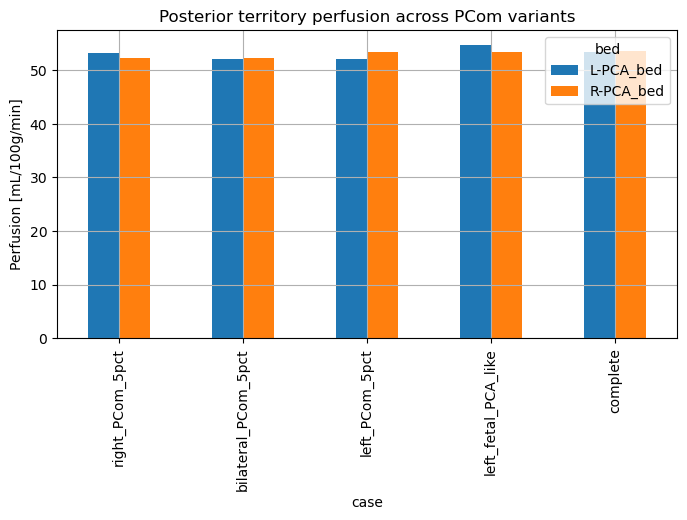

In [15]:
if RUN_SIMULATIONS:
    pivot = bed_summary.pivot_table(
        index='case',
        columns='bed',
        values='Perfusion [mL/100g/min]',
    )
    display(pivot)
    pivot[['L-PCA_bed', 'R-PCA_bed']].sort_values(by='R-PCA_bed').plot(kind='bar', figsize=(8, 4), grid=True, )
    plt.ylabel('Perfusion [mL/100g/min]')
    plt.title('Posterior territory perfusion across PCom variants')
    plt.show()

## Discussion prompts

Use this experiment to discuss:

- Whether PCom hypoplasia changes PCA perfusion under normal inlet pressures.
- Whether the fetal-PCA-like surrogate shifts the supply of the left PCA territory toward the carotid side.
- Whether PCom flow direction changes relative to the complete CoW case.

If the changes are small, that is still useful: it means the baseline pressure and resistance choices make the system robust under resting conditions. The stronger test is to combine this notebook with ICA or basilar stenosis.